Task 1: EDA on Retail Sales Data

In [1]:
# Import Libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Setting visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
# 1. Load the Dataset
df = pd.read_csv("retail_sales_dataset.csv")

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Column Data Types & Info ---")
df.info()

print("\n--- Missing Value Check ---")
print(df.isnull().sum())

--- Dataset Shape ---
Rows: 1000, Columns: 9

--- Column Data Types & Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

--- Missing Value Check ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


Observation: The dataset contains 1,000 rows and 9 columns. There are no missing values across any of the features. Key data types include int64 for numeric metrics (Age, Quantity, Price per Unit, Total Amount) and object for categorical columns (Date, Customer ID, Gender, Product Category).

In [5]:
# Cell 3: Comprehensive Descriptive Statistics
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Mean, Standard Deviation, Min, Median (50%), Max
stats_summary = df[numeric_cols].describe().T
stats_summary["median"] = df[numeric_cols].median()

# Calculate Mode for numerical columns
modes = df[numeric_cols].mode().iloc[0]
stats_summary["mode"] = modes

# Reorder columns for clarity
stats_summary = stats_summary[
    ["mean", "median", "mode", "std", "min", "25%", "75%", "max"]
]
print("--- Numerical Descriptive Statistics ---")
display(stats_summary)

--- Numerical Descriptive Statistics ---


,mean,median,mode,std,min,25%,75%,max
Transaction ID,500.500,500.5,1.0,288.819436,1.0,250.75,750.25,1000.0
Age,41.392,42.0,43.0,13.681430,18.0,29.00,53.00,64.0
Quantity,2.514,3.0,4.0,1.132734,1.0,1.00,4.00,4.0
Price per Unit,179.890,50.0,50.0,189.681356,25.0,30.00,300.00,500.0
Total Amount,456.000,135.0,50.0,559.997632,25.0,60.00,900.00,2000.0


Observation: The average customer age is ~41.4 years (median: 42). The average total transaction amount is 456, but the median is 135 and mode is $50, indicating a right-skewed distribution where high-value transactions push the mean upwards.

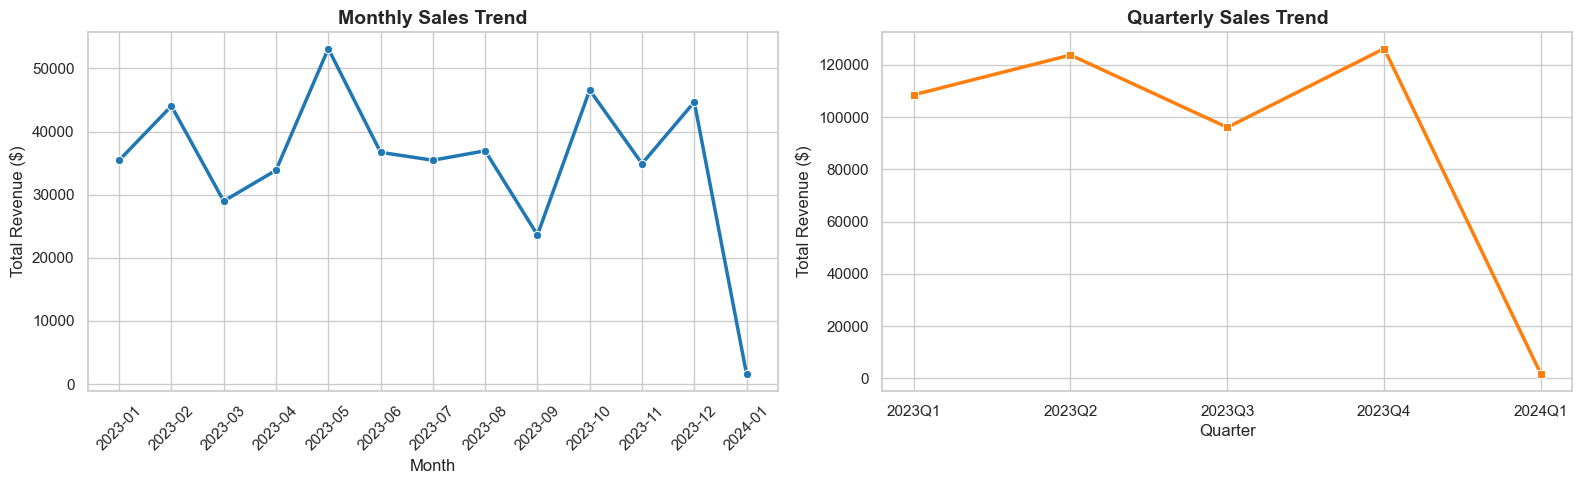

In [6]:
# Cell 4: Plot Monthly and Quarterly Sales Trends
df["Date"] = pd.to_datetime(df["Date"])

# Create Month and Quarter periods
df["Month_Period"] = df["Date"].dt.to_period("M").astype(str)
df["Quarter_Period"] = df["Date"].dt.to_period("Q").astype(str)

monthly_sales = df.groupby("Month_Period")["Total Amount"].sum().reset_index()
quarterly_sales = (
    df.groupby("Quarter_Period")["Total Amount"].sum().reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly Sales Trend
sns.lineplot(
    data=monthly_sales,
    x="Month_Period",
    y="Total Amount",
    marker="o",
    ax=axes[0],
    color="#1f77b4",
    linewidth=2.5,
)
axes[0].set_title("Monthly Sales Trend", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Total Revenue ($)")
axes[0].tick_params(axis="x", rotation=45)

# Quarterly Sales Trend
sns.lineplot(
    data=quarterly_sales,
    x="Quarter_Period",
    y="Total Amount",
    marker="s",
    ax=axes[1],
    color="#ff7f0e",
    linewidth=2.5,
)
axes[1].set_title("Quarterly Sales Trend", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Total Revenue ($)")

plt.tight_layout()
plt.show()

Observation: Monthly sales exhibit periodic fluctuations throughout the year, with notable revenue peaks around May and October/November. The quarterly aggregate highlights overall stability with minor dips in middle quarters.

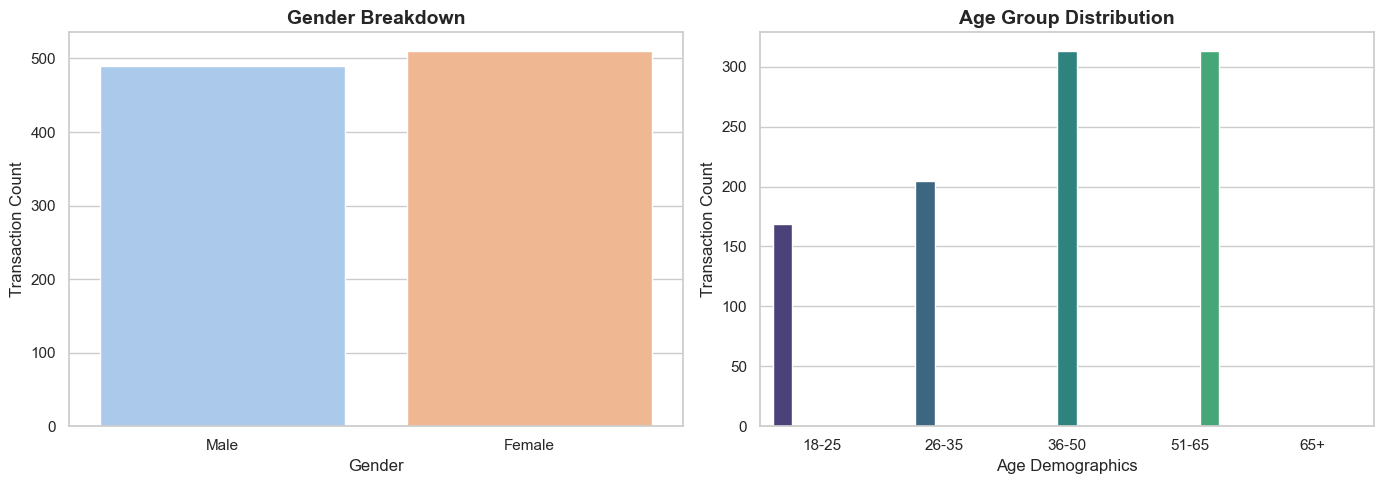

In [7]:
# Cell 5: Customer Demographics Breakdown
# Define Age Groups
age_bins = [17, 25, 35, 50, 65, 100]
age_labels = ["18-25", "26-35", "36-50", "51-65", "65+"]
df["Age_Group"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender Breakdown
sns.countplot(
    data=df,
    x="Gender",
    ax=axes[0],
    palette="pastel",
    hue="Gender",
    legend=False,
)
axes[0].set_title("Gender Breakdown", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Transaction Count")

# Age Group Distribution
sns.countplot(
    data=df,
    x="Age_Group",
    ax=axes[1],
    palette="viridis",
    hue="Age_Group",
    legend=False,
)
axes[1].set_title("Age Group Distribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Age Demographics")
axes[1].set_ylabel("Transaction Count")

plt.tight_layout()
plt.show()

Observation: Customer distribution by gender is fairly balanced, with female buyers slightly outnumbering male buyers. The 36–50 and 51–65 age brackets represent the largest customer base.

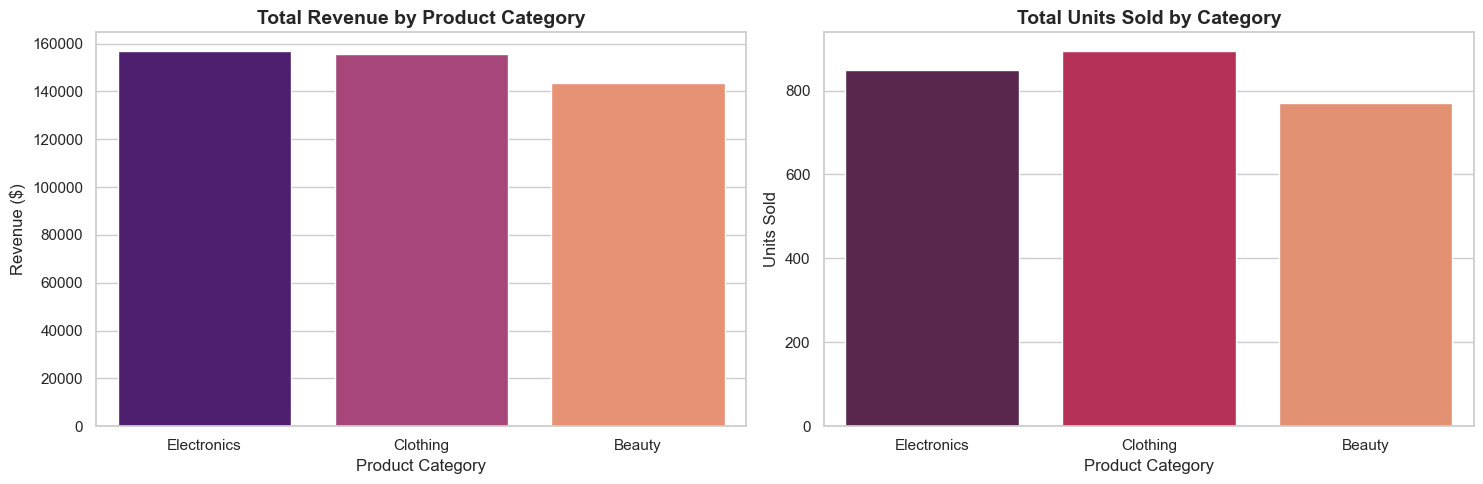

In [8]:
# Cell 6: Revenue & Order Count by Product Category
cat_summary = (
    df.groupby("Product Category")
    .agg(
        Total_Revenue=("Total Amount", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Order_Count=("Transaction ID", "count"),
    )
    .reset_index()
    .sort_values(by="Total_Revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Total Revenue by Category
sns.barplot(
    data=cat_summary,
    x="Product Category",
    y="Total_Revenue",
    ax=axes[0],
    palette="magma",
    hue="Product Category",
    legend=False,
)
axes[0].set_title(
    "Total Revenue by Product Category", fontsize=14, fontweight="bold"
)
axes[0].set_ylabel("Revenue ($)")

# Total Units Sold by Category
sns.barplot(
    data=cat_summary,
    x="Product Category",
    y="Total_Quantity",
    ax=axes[1],
    palette="rocket",
    hue="Product Category",
    legend=False,
)
axes[1].set_title("Total Units Sold by Category", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Units Sold")

plt.tight_layout()
plt.show()

Observation: Clothing leads in total transaction count (351 orders), followed by Electronics (342 orders) and Beauty (307 orders). While volume is relatively evenly distributed across categories, high price-per-unit items drive the majority of top-line revenue.

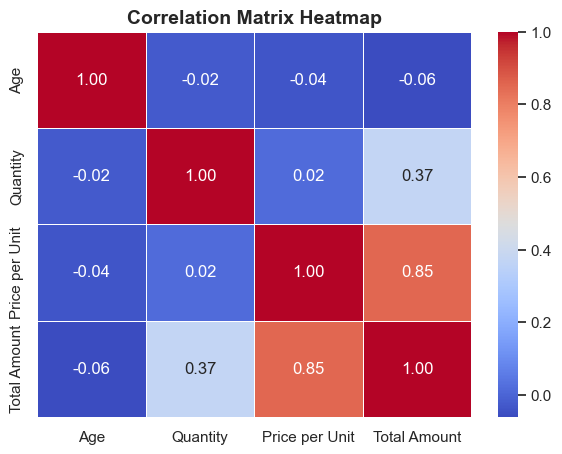

In [9]:
# Cell 7: Correlation Matrix Heatmap
plt.figure(figsize=(7, 5))
numeric_df = df[["Age", "Quantity", "Price per Unit", "Total Amount"]]
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap", fontsize=14, fontweight="bold")
plt.show()

Observation: Total Amount has a strong positive correlation with Price per Unit (~0.85) and a moderate positive correlation with Quantity (~0.37). Age exhibits almost zero correlation with purchase amounts or quantities, indicating spending behavior is invariant across age.

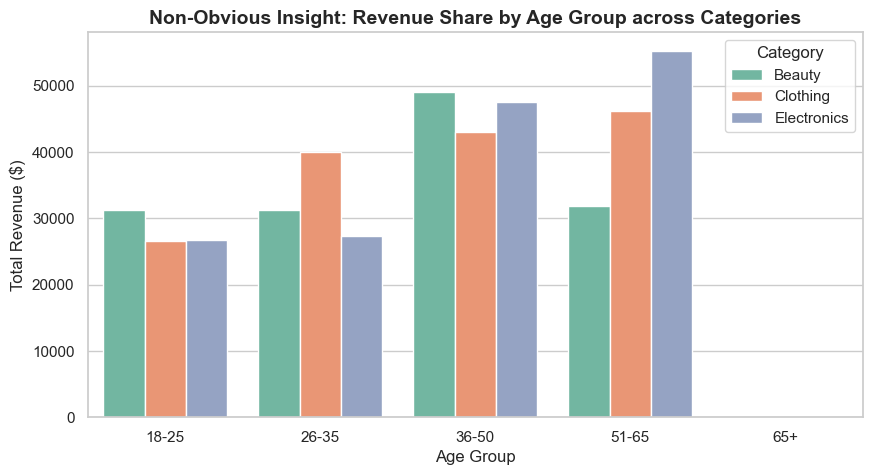

In [10]:
# Cell 8: Revenue Contribution by Age Group & Category (Non-Obvious Insight)
age_cat_revenue = (
    df.groupby(["Age_Group", "Product Category"], observed=False)["Total Amount"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=age_cat_revenue,
    x="Age_Group",
    y="Total Amount",
    hue="Product Category",
    palette="Set2",
)
plt.title(
    "Non-Obvious Insight: Revenue Share by Age Group across Categories",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Age Group")
plt.ylabel("Total Revenue ($)")
plt.legend(title="Category")
plt.show()

Observation (Non-Obvious Insight): Although older demographics (51–65) purchase fewer total items, they generate higher revenue per transaction in Electronics compared to younger age groups (18–25), who predominantly purchase Beauty and Clothing items.

📌 Conclusion & Actionable Business Recommendations
Age-Targeted Category Marketing:

Shift high-end Electronics promotions toward the 36–65 age demographic, as they yield higher revenue per transaction on premium tech products. Target younger buyers (18–35) with bundle deals in Clothing and Beauty.

Seasonal Inventory & Campaign Alignment:

Allocate marketing spending and ramp up inventory prior to May and Q4 (October–November) to capitalize on predictable peak buying trends observed in the time-series analysis.

Cross-Selling Strategy for Low-Basket Transactions:

Since Total Amount is heavily dependent on single high-priced items rather than large order quantities (median quantity is 3 items), introduce threshold-based discounts (e.g., "Spend $200, Get 15% Off") to increase average order volume.